# Elaboró:
Rojas Martinez Jonathan Francisco

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Cargar una imagen

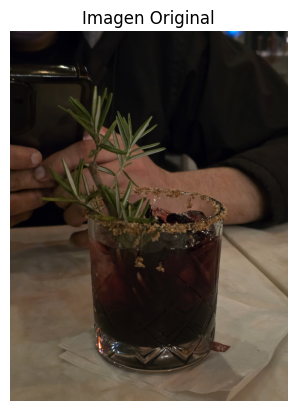

In [3]:
img = cv2.imread('../imagenes/Bebida_restaurant.jpg')
if img is None:
    raise ValueError("No se pudo cargar la imagen")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis('off')
plt.show()

## Girar la imagen verticalmente

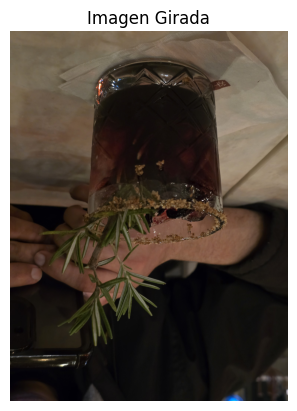

In [4]:
img_girada = cv2.flip(img, 0)
plt.imshow(cv2.cvtColor(img_girada, cv2.COLOR_BGR2RGB))
plt.title("Imagen Girada")
plt.axis('off')
plt.show()

## Convertir a escala de grises con 10% R, 5% G y 85% G

(np.float64(-0.5), np.float64(2999.5), np.float64(3999.5), np.float64(-0.5))

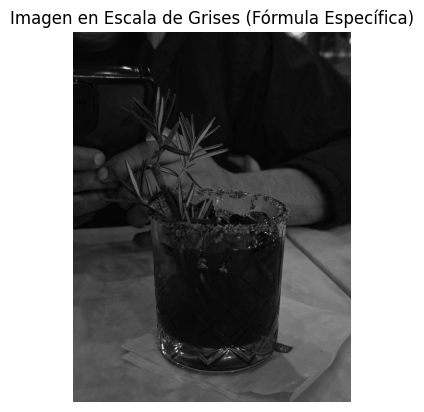

In [5]:
b, g, r = cv2.split(img)
gris_especifico = (0.10 * r + 0.05 * g + 0.85 * b).astype(np.uint8)
plt.imshow(gris_especifico, cmap='gray')
plt.title("Imagen en Escala de Grises (Fórmula Específica)")
plt.axis('off')

## Convertir a grises con fórmula

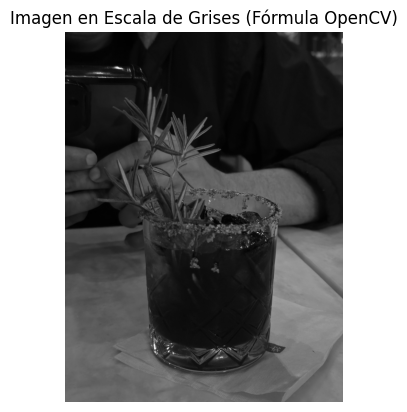

In [6]:
gray_formula = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_formula, cmap='gray')
plt.title("Imagen en Escala de Grises (Fórmula OpenCV)")
plt.axis('off')
plt.show()

## Aplicar detección de bordes (Sobel y Prewitt)

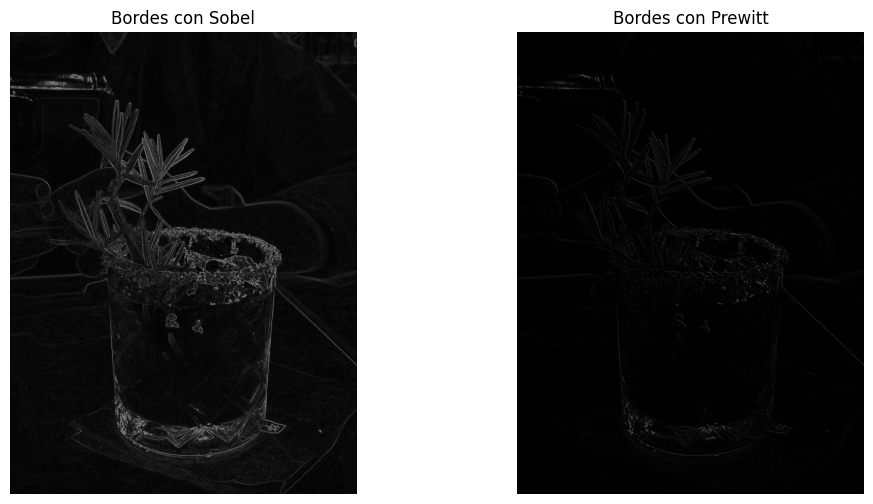

In [ ]:
# -- Filtro Sobel --
sobel_x = cv2.Sobel(gray_formula, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_formula, cv2.CV_64F, 0, 1, ksize=3)
sobel_combinado = np.uint8(np.absolute(sobel_x) + np.absolute(sobel_y))

# -- Filtro Prewitt --
kernel_prewitt_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
kernel_prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
prewitt_x = cv2.filter2D(gray_formula, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(gray_formula, -1, kernel_prewitt_y)
prewitt_combinado = cv2.addWeighted(np.absolute(prewitt_x), 0.5, np.absolute(prewitt_y), 0.5, 0)
prewitt_combinado = np.uint8(prewitt_combinado)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(sobel_combinado, cmap='gray')
plt.title("Bordes con Sobel")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(prewitt_combinado, cmap='gray')
plt.title("Bordes con Prewitt")
plt.axis('off')
plt.show()

## Umbralizar a 50, 100 y 150

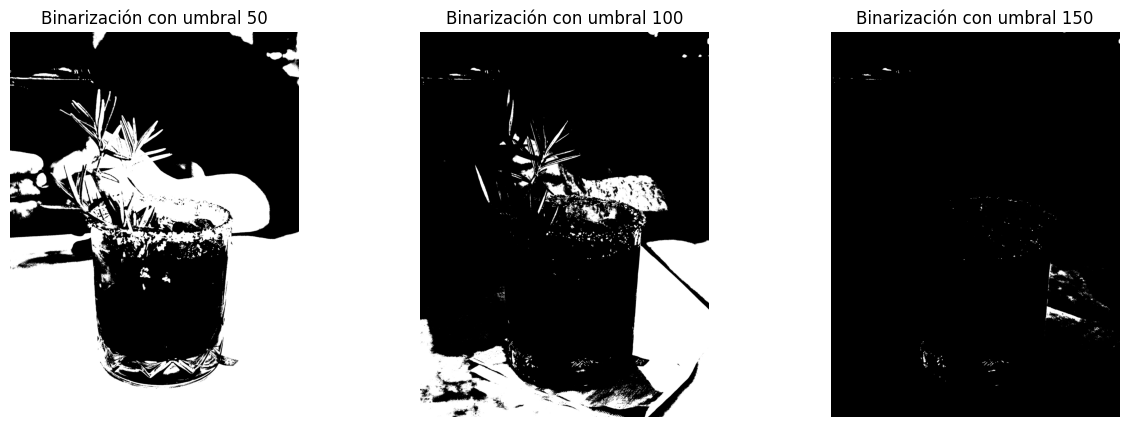

In [8]:
_, bin_50 = cv2.threshold(gray_formula, 50, 255, cv2.THRESH_BINARY)
_, bin_100 = cv2.threshold(gray_formula, 100, 255, cv2.THRESH_BINARY)
_, bin_150 = cv2.threshold(gray_formula, 150, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(bin_50, cmap='gray')
plt.title("Binarización con umbral 50")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(bin_100, cmap='gray')
plt.title("Binarización con umbral 100")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(bin_150, cmap='gray')
plt.title("Binarización con umbral 150")
plt.axis('off')
plt.show()

## Dibujar un cuadro azul y colocarlo en una imagen

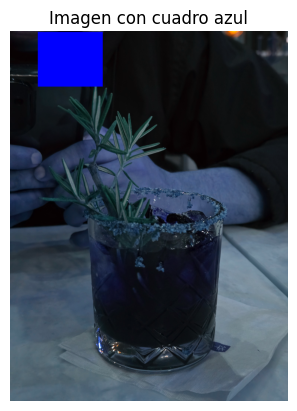

In [26]:
img_cuadro = img.copy()
cv2.rectangle(img_cuadro, (300, 600), (1000, 10), (0, 0, 255), -1)

plt.imshow(img_cuadro)
plt.title("Imagen con cuadro azul")
plt.axis('off')
plt.show()

## Nueva imagen

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

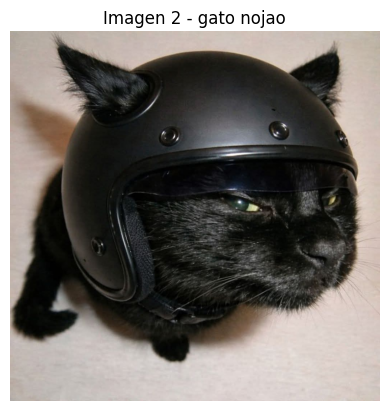

In [27]:
img_02 = cv2.imread('../imagenes/gato_nojao.jpg')
if img_02 is None:
    raise ValueError("No se pudo cargar la imagen")
img_02_gris = cv2.cvtColor(img_02, cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(img_02, cv2.COLOR_BGR2RGB))
plt.title("Imagen 2 - gato nojao")
plt.axis('off')

## Erosionar tamaño 5 y dilatación de 7

Dimensiones de la imagen original: (1024, 1024)


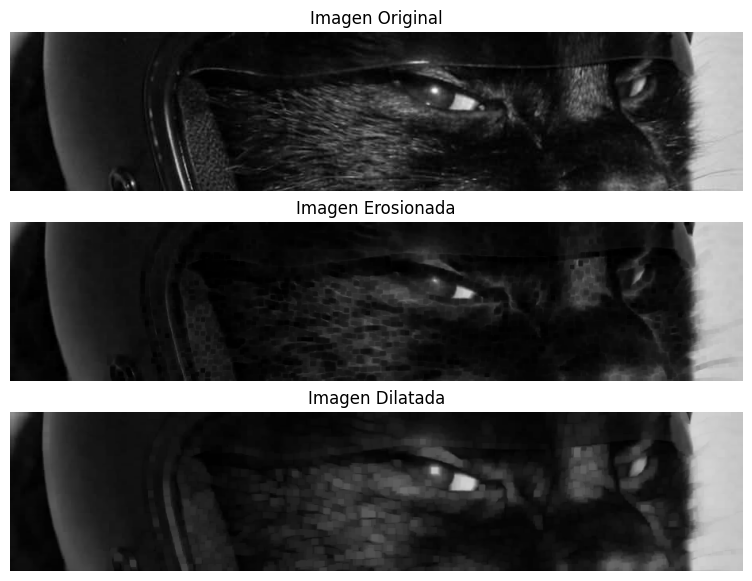

In [28]:
# Recotamos la imagen para enfocarnos en un punto y ver mejor la erosión y dilatación
print(f"Dimensiones de la imagen original: {img_02_gris.shape}")

img_02_gris_recortada = img_02_gris[400:600, 100:2000]

# Kernels
kernel_erosion = np.ones((5, 5), np.uint8)
kernel_dilatacion = np.ones((7, 7), np.uint8)
# Imagenes
img_erosionada = cv2.erode(img_02_gris_recortada, kernel_erosion, iterations=1)
img_dilatada = cv2.dilate(img_erosionada, kernel_dilatacion, iterations=1)

plt.figure(figsize=(10, 7))
plt.subplot(3, 1, 1)
plt.imshow(cv2.cvtColor(img_02_gris_recortada, cv2.COLOR_GRAY2RGB))
plt.title("Imagen Original")
plt.axis('off')
plt.subplot(3, 1, 2)
plt.imshow(cv2.cvtColor(img_erosionada, cv2.COLOR_GRAY2RGB))
plt.title("Imagen Erosionada")
plt.axis('off')
plt.subplot(3, 1, 3)
plt.imshow(cv2.cvtColor(img_dilatada, cv2.COLOR_GRAY2RGB))
plt.title("Imagen Dilatada")
plt.axis('off')
plt.show()

## Aplicar ORB, mostrar que identificó en la imagen misma

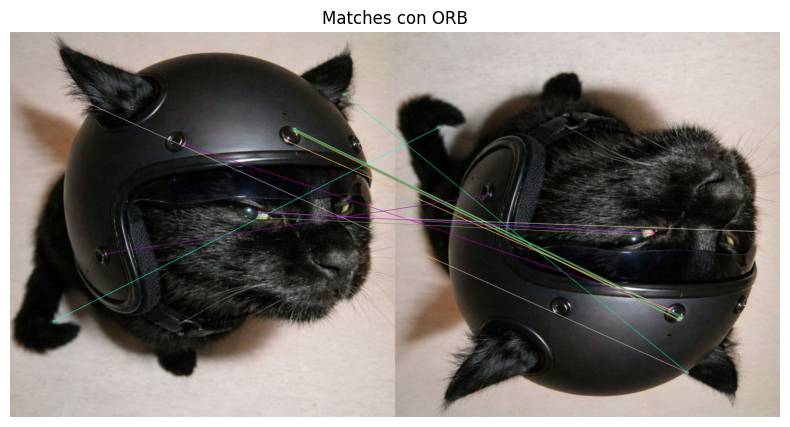

In [29]:
# Imagen girada
img_02_girada = cv2.flip(img_02, 0)

# Aplicar ORB y hacer match con la imagen girada
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img_02, None)
kp2, des2 = orb.detectAndCompute(img_02_girada, None)

# Emparejar las características detectadas mediante fuerza bruta usando distancia de Hamming
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance) # Ordenar por los mejores matches

# Visualizar el resultado de la identificación
img_matches = cv2.drawMatches(img_02, kp1, img_02_girada, kp2, matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Matches con ORB")
plt.axis('off')
plt.show()



## Fusionar 2 imagenes

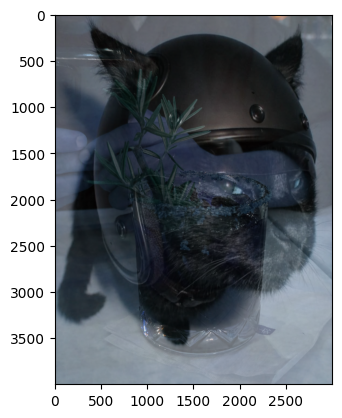

In [30]:
# Redimensionar img3 para que coincida con img
img3_resized = cv2.resize(img_02, (img.shape[1], img.shape[0]))
img_fusionada = cv2.addWeighted(img, 0.5, img3_resized, 0.5, 0)
cv2.imwrite('imagen_fusionada.jpg', img_fusionada)

plt.imshow(img_fusionada)